#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
print("All good 🚀")

All good 🚀


##### Load dataset

In [21]:
model_df = pd.read_csv("../data/processed/bed_occupancy_timeseries.csv")

In [3]:
model_df.duplicated(
    [
        "hospital_id",
        "ward",
        "date"
    ]
).sum()

0

In [4]:
units = (
    model_df[
        [
            "hospital_id",
            "ward"
        ]
    ]
    .drop_duplicates()
)

print("Number of units:", len(units))

units.head()

Number of units: 40


,hospital_id,ward
0,HHN-BIR-01,Cardiology Ward
731,HHN-BIR-01,Day Case Unit
1462,HHN-BIR-01,General Medicine Ward A
2193,HHN-BIR-01,General Medicine Ward B
2924,HHN-BIR-01,Icu


##### SARIMAX forecasting 24-72 hours

In [5]:
failed_units = []

results = []

forecast_results = []

for index, row in units.iterrows():

    hospital_id = row["hospital_id"]
    ward = row["ward"]

    try:

        unit_df = model_df[
            (model_df["hospital_id"] == hospital_id) &
            (model_df["ward"] == ward)
        ].copy()

        unit_df = unit_df.sort_values("date")

        unit_df = unit_df.set_index("date")

        # Target variable
        y = unit_df["occupied_beds"]

        # Exogenous variables
        exog_features = [
             # patient flow drivers
            "daily_admissions",
            "daily_discharges",
            "emergency_admissions",
            "daily_ed_arrivals",
            "scheduled_surgeries",

            # Patient stay characteristics
            "avg_los_hours",
            "avg_los_days",

            # Staffing factors
            "planned_staff",
            "actual_staff",
            "staffing_ratio",

            # seasonal effects
            "day_of_week",
            "month",
            "quarter",
            "is_weekend",
            "is_holiday",
            "week_of_year",

            # Operational pressure indicators
            "admission_pressure",
            "staff_shortage",
            "emergency_ratio",
            "surgery_per_staff"
        ]

        X = unit_df[exog_features].fillna(0)

        # Train/Test split (last 3 days)
        train = y.iloc[:-3]
        test = y.iloc[-3:]

        X_train = X.iloc[:-3]
        X_test = X.iloc[-3:]

        # Build SARIMAX model
        model = SARIMAX(
            train,
            exog=X_train,
            order=(1,0,1),
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model.fit(disp=False)

        # Forecast next 3 days
        forecast = model_fit.forecast(
            steps=3,
            exog=X_test
        )
        # 
        forecast_dates = test.index

        for date, pred, actual in zip(
            forecast_dates,
            forecast,
            test
        ):
            forecast_results.append(
                {
                    "hospital_id": hospital_id,
                    "ward": ward,
                    "date": date,
                    "actual_occupied_beds": actual,
                    "forecast_occupied_beds": round(pred, 2)
                }
            )
        # Evaluation
        mae = mean_absolute_error(
            test,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        def smape(actual, forecast):

            actual = np.array(actual)
            forecast = np.array(forecast)

            return (
                np.mean(
                    2 * np.abs(forecast - actual) /
                    (np.abs(actual) + np.abs(forecast) + 1e-8)
                )
                * 100
            )
        smape_value = smape(test, forecast)

        results.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "MAE": round(mae, 2),
                "RMSE": round(rmse, 2),
                "sMAPE": round(smape_value, 2)
            }
        )

    except Exception as e:

        failed_units.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "error": str(e)
            }
        )

c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Abdiel\AppData\Local\Progra

In [50]:
import joblib

In [51]:
joblib.dump(
    model_fit,
    "../models/sarimax/sarimax_24_72h.pkl"
)

['../models/sarimax/sarimax_24_72h.pkl']

In [55]:
forecast_df = pd.DataFrame(forecast_results)

forecast_df.to_csv(
    "../data/processed/sarimax_24_72_forecast.csv",
    index=False
)

In [6]:
forecast_df = pd.DataFrame(forecast_results)

forecast_df.head()


,hospital_id,ward,date,actual_occupied_beds,forecast_occupied_beds
0,HHN-BIR-01,Cardiology Ward,2025-12-29,17,22.62
1,HHN-BIR-01,Cardiology Ward,2025-12-30,15,22.70
2,HHN-BIR-01,Cardiology Ward,2025-12-31,14,22.76
3,HHN-BIR-01,Day Case Unit,2025-12-29,0,0.60
4,HHN-BIR-01,Day Case Unit,2025-12-30,0,0.59


In [7]:
forecast_df[
    (forecast_df["hospital_id"]=="HHN-BIR-01") &
    (forecast_df["ward"]=="Cardiology Ward")
]

,hospital_id,ward,date,actual_occupied_beds,forecast_occupied_beds
0,HHN-BIR-01,Cardiology Ward,2025-12-29,17,22.62
1,HHN-BIR-01,Cardiology Ward,2025-12-30,15,22.70
2,HHN-BIR-01,Cardiology Ward,2025-12-31,14,22.76


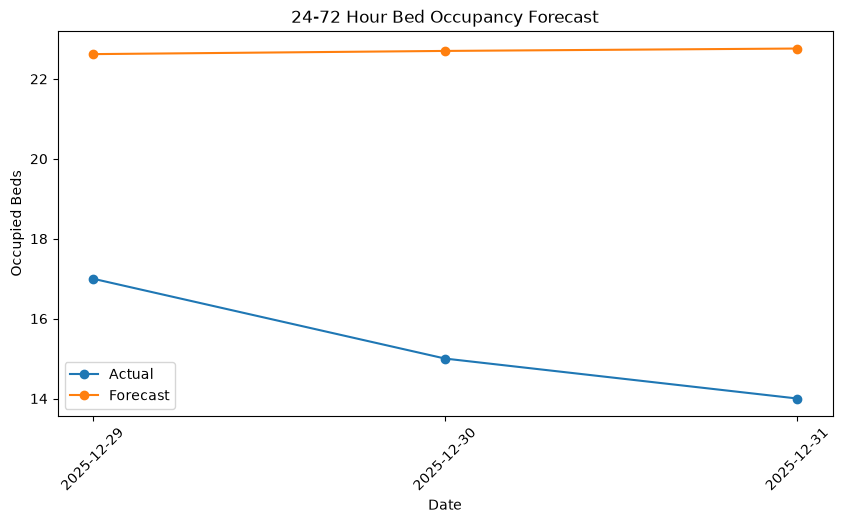

In [8]:
unit_forecast = forecast_df[
    (forecast_df["hospital_id"]=="HHN-BIR-01") &
    (forecast_df["ward"]=="Cardiology Ward")
]

plt.figure(figsize=(10,5))

plt.plot(
    unit_forecast["date"],
    unit_forecast["actual_occupied_beds"],
    marker="o",
    label="Actual"
)

plt.plot(
    unit_forecast["date"],
    unit_forecast["forecast_occupied_beds"],
    marker="o",
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Occupied Beds")
plt.title("24-72 Hour Bed Occupancy Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.show()

24-72 hours forecast predicts stable occupancy around 22–23 beds, while the actual occupancy shows a declining trend from 17 to 14 beds over the same period. The model is overestimating future demand and is not capturing the recent downward movement in occupancy. The forecast currently lacks accuracy for short-term operational decisions.

In [9]:
print("Successful models:", len(results))

Successful models: 40


In [10]:
failed_df = pd.DataFrame(failed_units)

print("Failed models:", len(failed_df))

Failed models: 0


In [11]:
results_df = pd.DataFrame(results)

results_df

,hospital_id,ward,MAE,RMSE,sMAPE
0,HHN-BIR-01,Cardiology Ward,7.36,7.48,38.96
1,HHN-BIR-01,Day Case Unit,0.61,0.61,200.00
2,HHN-BIR-01,General Medicine Ward A,1.00,1.11,6.52
3,HHN-BIR-01,General Medicine Ward B,0.89,1.20,5.31
4,HHN-BIR-01,Icu,1.03,1.04,12.18
5,HHN-BIR-01,Oncology Ward,2.28,2.43,20.17
6,HHN-BIR-01,Orthopaedics Ward A,0.41,0.45,3.82
7,HHN-BIR-01,Orthopaedics Ward B,0.65,0.75,6.49
8,HHN-EDI-01,Cardiology Ward,2.31,2.32,15.89
9,HHN-EDI-01,Day Case Unit,0.33,0.40,143.92


#### SARIMAX Short-Term Forecast Performance (24–72 Hours)

The SARIMAX model was evaluated across 40 hospital units (hospital × ward combinations) using three performance metrics:
MAE (Mean Absolute Error): Average number of beds the prediction differs from the actual occupancy.
RMSE (Root Mean Squared Error): Similar to MAE but gives greater weight to larger forecasting errors.
sMAPE (Symmetric Mean Absolute Percentage Error): Percentage-based forecast accuracy that remains reliable even when occupancy is low or occasionally zero.

#### Most inpatient wards were forecast accurately

Overall findings across Cardiology, General Medicine, Orthopaedics, Oncology and ICU wards, the model generally produced:
MAE between 0.5 and 3 beds
RMSE close to the MAE, indicating few large forecasting errors
sMAPE typically between 3% and 20%

The SARIMAX model successfully captured short-term bed occupancy patterns across all hospital units. Most inpatient wards achieved forecasting errors of fewer than three beds and sMAPE values below 20%, demonstrating good predictive performance. Higher percentage errors observed in Day Case Units are primarily due to very low occupancy levels rather than poor model accuracy

##### SARIMAX forecasting 7-30 days

In [12]:
failed_units = []

results_30 = []

forecast_res = []

for index, row in units.iterrows():

    hospital_id = row["hospital_id"]
    ward = row["ward"]

    try:

        unit_df = model_df[
            (model_df["hospital_id"] == hospital_id) &
            (model_df["ward"] == ward)
        ].copy()

        unit_df = unit_df.sort_values("date")
        unit_df = unit_df.set_index("date")

        # ----------------------------
        # Target
        # ----------------------------

        y = unit_df["occupied_beds"]

        # ----------------------------
        # Exogenous variables
        # ----------------------------

        exog_features = [

            # patient flow drivers
            "daily_admissions",
            "daily_discharges",
            "emergency_admissions",
            "daily_ed_arrivals",
            "scheduled_surgeries",

            # Patient stay characteristics
            "avg_los_hours",
            "avg_los_days",

            # Staffing factors
            "planned_staff",
            "actual_staff",
            "staffing_ratio",

            # seasonal effects
            "day_of_week",
            "month",
            "quarter",
            "is_weekend",
            "is_holiday",
            "week_of_year",

            # Operational pressure indicators
            "admission_pressure",
            "staff_shortage",
            "emergency_ratio",
            "surgery_per_staff"
        ]

        X = unit_df[exog_features].fillna(0)

        # ----------------------------
        # Train/Test Split
        # Last 30 days
        # ----------------------------

        train = y.iloc[:-30]
        test = y.iloc[-30:]

        X_train = X.iloc[:-30]
        X_test = X.iloc[-30:]

        # ----------------------------
        # SARIMAX
        # ----------------------------

        model = SARIMAX(
            train,
            exog=X_train,
            order=(1,0,1),
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model.fit(disp=False)

        # ----------------------------
        # Forecast 30 days
        # ----------------------------

        forecast = model_fit.forecast(
            steps=30,
            exog=X_test
        )

        # ----------------------------
        # Save Forecasts
        # ----------------------------

        forecast_dates = test.index

        for date, pred, actual in zip(
            forecast_dates,
            forecast,
            test
        ):

            forecast_res.append(
                {
                    "hospital_id": hospital_id,
                    "ward": ward,
                    "date": date,
                    "actual_occupied_beds": actual,
                    "forecast_occupied_beds": round(pred, 2)
                }
            )

        # ----------------------------
        # Evaluation
        # ----------------------------

        mae = mean_absolute_error(
            test,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        def smape(actual, forecast):

            actual = np.array(actual)
            forecast = np.array(forecast)

            return (
                np.mean(
                    2 * np.abs(forecast - actual) /
                    (
                        np.abs(actual) +
                        np.abs(forecast) +
                        1e-8
                    )
                ) * 100
            )

        smape_value = smape(
            test,
            forecast
        )

        results_30.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "MAE": round(mae, 2),
                "RMSE": round(rmse, 2),
                "sMAPE": round(smape_value, 2)
            }
        )

    except Exception as e:

        failed_units.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "error": str(e)
            }
        )

c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Abdiel\AppData\Local\Progra

In [52]:
joblib.dump(
    model_fit,
    "../models/sarimax/sarimax_3_30d.pkl"
)

['../models/sarimax/sarimax_3_30d.pkl']

In [13]:
forecast_df_30 = pd.DataFrame(forecast_res)
forecast_df_30.head()

,hospital_id,ward,date,actual_occupied_beds,forecast_occupied_beds
0,HHN-BIR-01,Cardiology Ward,2025-12-02,18,20.81
1,HHN-BIR-01,Cardiology Ward,2025-12-03,20,21.17
2,HHN-BIR-01,Cardiology Ward,2025-12-04,21,21.08
3,HHN-BIR-01,Cardiology Ward,2025-12-05,20,21.80
4,HHN-BIR-01,Cardiology Ward,2025-12-06,21,19.88


In [56]:
forecast_df_30.to_csv(
    "../data/processed/sarimax_7_30_forecast.csv",
    index=False
)

In [14]:
forecast_df_30[
    (forecast_df_30["hospital_id"] == "HHN-BIR-01") &
    (forecast_df_30["ward"] == "Cardiology Ward")
]

,hospital_id,ward,date,actual_occupied_beds,forecast_occupied_beds
0,HHN-BIR-01,Cardiology Ward,2025-12-02,18,20.81
1,HHN-BIR-01,Cardiology Ward,2025-12-03,20,21.17
2,HHN-BIR-01,Cardiology Ward,2025-12-04,21,21.08
3,HHN-BIR-01,Cardiology Ward,2025-12-05,20,21.80
4,HHN-BIR-01,Cardiology Ward,2025-12-06,21,19.88
5,HHN-BIR-01,Cardiology Ward,2025-12-07,17,17.45
6,HHN-BIR-01,Cardiology Ward,2025-12-08,19,17.84
7,HHN-BIR-01,Cardiology Ward,2025-12-09,19,18.68
8,HHN-BIR-01,Cardiology Ward,2025-12-10,17,20.50
9,HHN-BIR-01,Cardiology Ward,2025-12-11,16,21.32


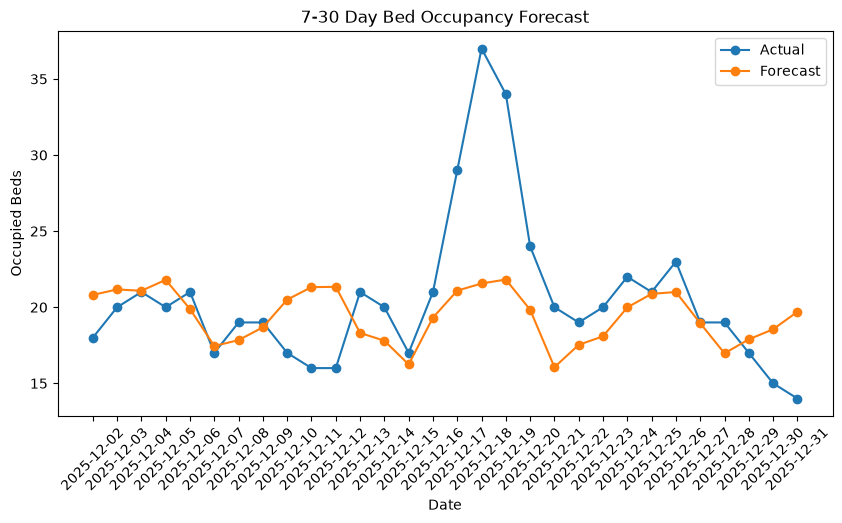

In [15]:
unit_forecast = forecast_df_30[
    (forecast_df_30["hospital_id"]=="HHN-BIR-01") &
    (forecast_df_30["ward"]=="Cardiology Ward")
]

plt.figure(figsize=(10,5))

plt.plot(
    unit_forecast["date"],
    unit_forecast["actual_occupied_beds"],
    marker="o",
    label="Actual"
)

plt.plot(
    unit_forecast["date"],
    unit_forecast["forecast_occupied_beds"],
    marker="o",
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Occupied Beds")
plt.title("7-30 Day Bed Occupancy Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.show()

The SARIMAX model successfully captures the underlying occupancy trend and average bed demand but does not accurately predict sudden surges in occupancy. It tends to smooth the forecasts, resulting in underestimation during periods of rapid demand increase

In [16]:
print("Successful models:", len(results))

Successful models: 40


In [17]:
failed_df = pd.DataFrame(failed_units)

print("Failed models:", len(failed_df))

Failed models: 0


In [18]:
results_df_30 = pd.DataFrame(results_30)

results_df_30

,hospital_id,ward,MAE,RMSE,sMAPE
0,HHN-BIR-01,Cardiology Ward,3.13,4.64,14.57
1,HHN-BIR-01,Day Case Unit,0.26,0.36,162.63
2,HHN-BIR-01,General Medicine Ward A,2.38,2.45,16.20
3,HHN-BIR-01,General Medicine Ward B,1.55,1.78,10.99
4,HHN-BIR-01,Icu,1.57,1.75,20.73
5,HHN-BIR-01,Oncology Ward,2.76,3.13,21.29
6,HHN-BIR-01,Orthopaedics Ward A,0.77,0.82,7.31
7,HHN-BIR-01,Orthopaedics Ward B,0.37,0.44,3.53
8,HHN-EDI-01,Cardiology Ward,3.22,3.53,24.20
9,HHN-EDI-01,Day Case Unit,0.20,0.28,180.50


### XGBoost 

In [22]:
from xgboost import XGBRegressor

In [23]:

failed_units_xgb = []

xgb_results = []


for index, row in units.iterrows():

    hospital_id = row["hospital_id"]
    ward = row["ward"]

    try:

        # Select one hospital ward
        unit_df = model_df[
            (model_df["hospital_id"] == hospital_id) &
            (model_df["ward"] == ward)
        ].copy()


        unit_df = unit_df.sort_values("date")

        # Features
        xgb_features = [
            # historical occupancy
            "lag_1_occupied_beds",
            "lag_7_occupied_beds",
            "rolling_7_day_avg",
            "rolling_7_day_std",

            # demand drivers
            "daily_admissions",
            "emergency_admissions",
            "daily_ed_arrivals",
            "scheduled_surgeries",

            # hospital capacity
            "total_beds",
            "staffed_beds",
            "closed_beds",

            # patient flow
            "avg_los_hours",

            # staffing
            "planned_staff",
            "actual_staff",
            "staffing_ratio",

            # calendar effects
            "day_of_week",
            "month",
            "quarter",
            "is_weekend",
            "is_holiday"
        ]


        X = unit_df[xgb_features]

        y = unit_df["occupied_beds"]


        # Last 30 days as test set
        X_train = X.iloc[:-30]
        X_test = X.iloc[-30:]

        y_train = y.iloc[:-30]
        y_test = y.iloc[-30:]


        # Build XGBoost model
        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            objective="reg:squarederror"
        )

        model.fit(
            X_train,
            y_train
        )


        # Forecast
        forecast_xgb = model.predict(
            X_test
        )


        # Evaluation

        mae = mean_absolute_error(
            y_test,
            forecast_xgb
        )


        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                forecast_xgb
            )
        )


        # sMAPE
        smape_value = (
            np.mean(
                2 * np.abs(forecast_xgb - y_test.values) /
                (
                    np.abs(y_test.values) +
                    np.abs(forecast_xgb) +
                    1e-8
                )
            )
            * 100
        )


        xgb_results.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "MAE": round(mae,2),
                "RMSE": round(rmse,2),
                "sMAPE": round(smape_value,2),
                "Model": "XGBoost"
            }
        )


    except Exception as e:

        failed_units_xgb.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "error": str(e)
            }
        )


# Convert results to dataframe

xgb_results_df = pd.DataFrame(xgb_results)


print("Number of units:", len(units))
print("Successful XGBoost models:", len(xgb_results_df))
print("Failed models:", len(failed_units_xgb))


xgb_results_df.head()

Number of units: 40
Successful XGBoost models: 40
Failed models: 0


,hospital_id,ward,MAE,RMSE,sMAPE,Model
0,HHN-BIR-01,Cardiology Ward,2.39,3.09,11.64,XGBoost
1,HHN-BIR-01,Day Case Unit,0.20,0.36,165.00,XGBoost
2,HHN-BIR-01,General Medicine Ward A,0.38,0.55,2.46,XGBoost
3,HHN-BIR-01,General Medicine Ward B,1.00,1.37,7.29,XGBoost
4,HHN-BIR-01,Icu,0.47,0.65,6.45,XGBoost


In [53]:
joblib.dump(
    model_fit,
    "../models/xgboost/xgboost_7_30d.pkl"
)

['../models/xgboost/xgboost_7_30d.pkl']

In [26]:
results_30_df = pd.DataFrame(results_30)

In [29]:
sarimax_results = results_30_df.rename(
    columns={
        "MAE": "SARIMAX_MAE",
        "RMSE": "SARIMAX_RMSE",
        "sMAPE": "SARIMAX_sMAPE"
    }
)

xgb_results = xgb_results_df.rename(
    columns={
        "MAE": "XGBoost_MAE",
        "RMSE": "XGBoost_RMSE",
        "sMAPE": "XGBoost_sMAPE"
    }
)

In [30]:
comparison_df = sarimax_results.merge(
    xgb_results,
    on=[
        "hospital_id",
        "ward"
    ],
    how="inner"
)

In [31]:
comparison_df["Better_Model"] = np.where(
    comparison_df["XGBoost_MAE"] < comparison_df["SARIMAX_MAE"],
    "XGBoost",
    "SARIMAX"
)

In [32]:
comparison_df[
    [
        "hospital_id",
        "ward",
        "SARIMAX_MAE",
        "XGBoost_MAE",
        "SARIMAX_RMSE",
        "XGBoost_RMSE",
        "SARIMAX_sMAPE",
        "XGBoost_sMAPE",
        "Better_Model"
    ]
]

,hospital_id,ward,SARIMAX_MAE,XGBoost_MAE,SARIMAX_RMSE,XGBoost_RMSE,SARIMAX_sMAPE,XGBoost_sMAPE,Better_Model
0,HHN-BIR-01,Cardiology Ward,3.13,2.39,4.64,3.09,14.57,11.64,XGBoost
1,HHN-BIR-01,Day Case Unit,0.26,0.20,0.36,0.36,162.63,165.00,XGBoost
2,HHN-BIR-01,General Medicine Ward A,2.38,0.38,2.45,0.55,16.20,2.46,XGBoost
3,HHN-BIR-01,General Medicine Ward B,1.55,1.00,1.78,1.37,10.99,7.29,XGBoost
4,HHN-BIR-01,Icu,1.57,0.47,1.75,0.65,20.73,6.45,XGBoost
5,HHN-BIR-01,Oncology Ward,2.76,1.32,3.13,1.66,21.29,10.74,XGBoost
6,HHN-BIR-01,Orthopaedics Ward A,0.77,0.14,0.82,0.22,7.31,1.26,XGBoost
7,HHN-BIR-01,Orthopaedics Ward B,0.37,0.36,0.44,0.53,3.53,3.45,XGBoost
8,HHN-EDI-01,Cardiology Ward,3.22,0.95,3.53,1.25,24.20,6.98,XGBoost
9,HHN-EDI-01,Day Case Unit,0.20,0.16,0.28,0.33,180.50,183.32,XGBoost


In [33]:
summary = pd.DataFrame({
    "Model": [
        "SARIMAX",
        "XGBoost"
    ],
    
    "Average_MAE": [
        comparison_df["SARIMAX_MAE"].mean(),
        comparison_df["XGBoost_MAE"].mean()
    ],
    
    "Average_RMSE": [
        comparison_df["SARIMAX_RMSE"].mean(),
        comparison_df["XGBoost_RMSE"].mean()
    ],
    
    "Average_sMAPE": [
        comparison_df["SARIMAX_sMAPE"].mean(),
        comparison_df["XGBoost_sMAPE"].mean()
    ]
})


summary.round(2)

,Model,Average_MAE,Average_RMSE,Average_sMAPE
0,SARIMAX,2.24,2.62,31.72
1,XGBoost,1.07,1.39,23.79


In [34]:
comparison_df["Better_Model"].value_counts()

Better_Model
XGBoost    40
Name: count, dtype: int64

##### Comparison of Models

In [39]:
print(xgb_results_df.head())

print(xgb_results_df.shape)

  hospital_id                     ward   MAE  RMSE   sMAPE    Model
0  HHN-BIR-01          Cardiology Ward  2.39  3.09   11.64  XGBoost
1  HHN-BIR-01            Day Case Unit  0.20  0.36  165.00  XGBoost
2  HHN-BIR-01  General Medicine Ward A  0.38  0.55    2.46  XGBoost
3  HHN-BIR-01  General Medicine Ward B  1.00  1.37    7.29  XGBoost
4  HHN-BIR-01                      Icu  0.47  0.65    6.45  XGBoost
(40, 6)


In [57]:
print(pd.read_csv("../data/processed/sarimax_24_72_forecast.csv").columns.tolist())

print(pd.read_csv("../data/processed/sarimax_7_30_forecast.csv").columns.tolist())

['hospital_id', 'ward', 'date', 'actual_occupied_beds', 'forecast_occupied_beds']
['hospital_id', 'ward', 'date', 'actual_occupied_beds', 'forecast_occupied_beds']


In [59]:
sarimax_short = pd.read_csv(
    "../data/processed/sarimax_24_72_forecast.csv"
)

sarimax_short = sarimax_short.rename(
    columns={
        "forecast_occupied_beds": "predicted_occupied_beds"
    }
)

sarimax_short.to_csv(
    "../data/processed/sarimax_24_72_forecast.csv",
    index=False
)

In [ ]:
sarimax_24_72_forecast_df.to_csv(
    "../data/processed/sarimax_24_72_forecast.csv",
    index=False
)

sarimax_7_30_forecast_df.to_csv(
    "../data/processed/sarimax_7_30_forecast.csv",
    index=False
)

In [60]:
print(pd.read_csv("../data/processed/sarimax_24_72_forecast.csv").columns)

print(pd.read_csv("../data/processed/sarimax_7_30_forecast.csv").columns)

Index(['hospital_id', 'ward', 'date', 'actual_occupied_beds',
       'predicted_occupied_beds'],
      dtype='str')
Index(['hospital_id', 'ward', 'date', 'actual_occupied_beds',
       'predicted_occupied_beds'],
      dtype='str')
